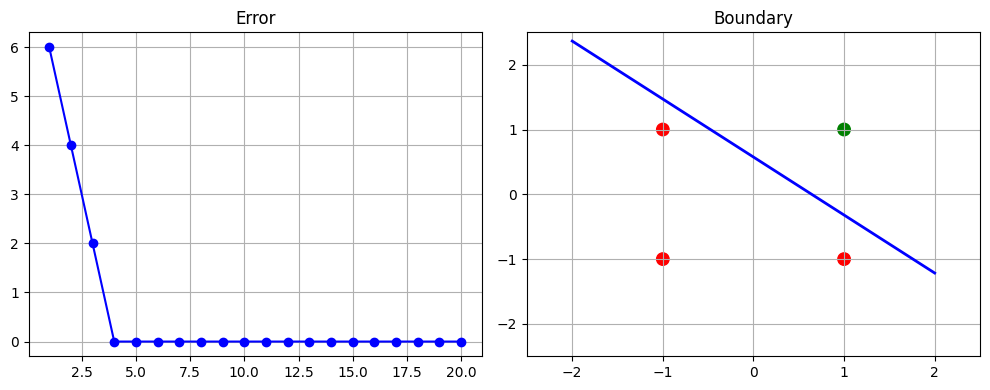

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# --- ১. ডাটা এবং প্রাথমিক সেটআপ ---
# ইনপুট ডাটা (X) এবং আসল উত্তর বা টার্গেট (T) সেট করা
X = np.array([[-1, -1], [-1, 1], [1, -1], [1, 1]])
T = np.array([-1, -1, -1, 1])

# ওয়েট (w) এবং বায়াস (b) আন্দাজে র্যান্ডম সংখ্যা ধরে নেওয়া
# লার্নিং রেট (lr) ০.১ এবং পুরো প্রসেসটি ২০ বার (epochs) চলবে
w, b, lr, epochs = np.random.rand(2), np.random.rand(), 0.1, 20
E = []  # প্রতি রাউন্ডে কতগুলো ভুল হলো তা জমা রাখার খালি লিস্ট

# --- ২. ট্রেনিং লুপ (AI এখানে শিখবে) ---
for ep in range(epochs):
    err = 0  # প্রতি রাউন্ডের শুরুতে ভুল বা এরর শূন্য (0) ধরে নেওয়া
    
    for i in range(4):  # ৪টি ডাটা পয়েন্ট এক এক করে চেক করার লুপ
        # নিউরনের হিসাব: মান ০ বা পজিটিভ হলে উত্তর ১, নেগেটিভ হলে -১
        y = 1 if np.dot(w, X[i]) + b >= 0 else -1
        
        # ভুল হিসাব করা: আসল উত্তর থেকে AI এর দেওয়া উত্তর বিয়োগ
        e = T[i] - y
        
        # ভুল হলে ফর্মুলা অনুযায়ী ওয়েট (w) এবং বায়াস (b) পরিবর্তন/আপডেট করা
        w += lr * e * X[i]
        b += lr * e
        
        # মোট ভুলের পরিমাণ যোগ করা (মাইনাস চিহ্ন বাদ দিয়ে শুধু মান)
        err += abs(e)
        
    E.append(err)  # গ্রাফে দেখানোর জন্য এই রাউন্ডের মোট ভুল লিস্টে জমা রাখা

# --- ৩. গ্রাফ তৈরি করা (ফলাফল দেখার জন্য) ---
plt.figure(figsize=(10, 4))  # উইন্ডোর সাইজ ঠিক করা

# বামপাশের গ্রাফ: রাউন্ড বাড়ার সাথে সাথে ভুল কীভাবে কমছে তা দেখা
plt.subplot(121)
plt.plot(range(1, 21), E, 'o-b')
plt.title('Error')
plt.grid()

# ডানপাশের গ্রাফ: ডাটা পয়েন্ট এবং বিভাজন রেখা (Decision Boundary) দেখা
plt.subplot(122)
# আসল উত্তর -১ হলে লাল (r) ডট আর ১ হলে সবুজ (g) ডট দেখানো
plt.scatter(X[:, 0], X[:, 1], c=['r' if t == -1 else 'g' for t in T], s=80)

# নিউরনের খুঁজে পাওয়া ওয়েট ও বায়াস দিয়ে একটি নীল রঙের সোজা বর্ডার লাইন টানা
x = np.array([-2, 2])  
plt.plot(x, -(w[0] * x + b) / w[1], 'b', lw=2)

# গ্রাফের চারপাশ সুন্দর করে সাজানো এবং স্ক্রিনে দেখানো
plt.title('Boundary')
plt.xlim([-2.5, 2.5])
plt.ylim([-2.5, 2.5])
plt.grid()

plt.tight_layout()
plt.show()